**Bellman Equations for Policy Search**

In this exercise, we are going to implement the Bellman equations for policy search in the next MDP, which we have already used previously:

![alt text](two_state_mdp.png "Title")

Let us start with the imports. We use numpy and matplotlib, and the magic command `%matplotlib inline` to show the results in the notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

The next thing we do is to seed the random number generator. This is done to ensure that the results are reproducible. At this point, this is not strictly necessary, but it is good practice to do so (and when working with Deep Reinforcement Learning, it is absolutely necessary).

In [2]:
rng = np.random.default_rng(1234)

Now, let us define the parameters of the problem. We have an MDP with two states, and two actions. The rewards, discount factor, and transition probabilities are given in the figure above. We also define the four possible deterministic policies as $\pi_1$, $\pi_2$, $\pi_3$, and $\pi_4$:

In [3]:
gamma = 0.9
R = np.array([[-1, 0.6, 0.5, -0.9]]).T
P = np.array([[0.8, 0.2], [0.2, 0.8], [0.3, 0.7], [0.9, 0.1]])
pi_1 = np.array([[1, 0, 0, 0], [0, 0, 1, 0]])
pi_2 = np.array([[0, 1, 0, 0], [0, 0, 1, 0]])
pi_3 = np.array([[1, 0, 0, 0], [0, 0, 0, 1]])
pi_4 = np.array([[0, 1, 0, 0], [0, 0, 0, 1]])

Now, let us implement the Bellman equations, using the fixed point equations seen in the slides.
* $v^{\pi} = \left( I - \gamma \mathcal{P}^{\pi} \right)^{-1} \mathcal{R}^{\pi}$
* $q^{\pi} = \left( I - \gamma \mathcal{P} \Pi \right)^{-1} \mathcal{R}$
Note that, attending to the results, we know that $\pi_2$ is the optimal policy, as it provides the highest value.

In [4]:
def bellman_equations(R, P, gamma, pi):
    num_states = pi.shape[0]
    I = np.eye(num_states)
    
    # Calculate expected rewards and transition dynamics
    R_pi = np.dot(pi, R)
    P_pi = np.dot(pi, P)
    
    # Solve for state values: v^pi = (I - gamma * P^pi)^-1 * R^pi
    v_pi = np.dot(np.linalg.inv(I - gamma * P_pi), R_pi)
    
    return v_pi

for pi in [pi_1, pi_2, pi_3, pi_4]:
    v_pi = bellman_equations(R, P, gamma, pi)
    with np.printoptions(precision=2, suppress=True):
        print(f"Policy = {pi.flatten()}")
        print(f"v^pi = {v_pi.flatten()}")

Policy = [1 0 0 0 0 0 1 0]
v^pi = [-5.09 -2.36]
Policy = [0 1 0 0 0 0 1 0]
v^pi = [5.34 5.25]
Policy = [1 0 0 0 0 0 0 1]
v^pi = [-9.83 -9.74]
Policy = [0 1 0 0 0 0 0 1]
v^pi = [-0.63 -1.55]


Now, we are going to evaluate many random policies, and store their values.

Image successfully saved to: /Users/anmolguragain/Desktop/semester2/drl_classes/homework_images/exercise_3_5.png


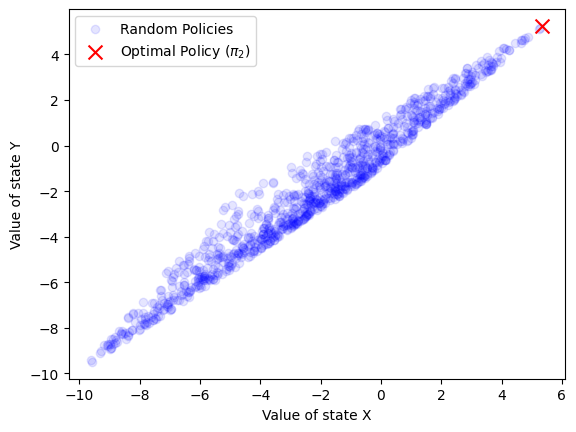

In [8]:
import os

n_policies_to_test = 1000  # Number of random policies to test
values = []  # List to store the values of the policies

for _ in range(n_policies_to_test):
    # State 0 action probabilities (must sum to 1)
    p_a0_s0 = rng.random()
    p_a1_s0 = 1.0 - p_a0_s0
    
    # State 1 action probabilities (must sum to 1)
    p_a0_s1 = rng.random()
    p_a1_s1 = 1.0 - p_a0_s1
    
    # Construct the stochastic policy matrix
    pi_random = np.array([
        [p_a0_s0, p_a1_s0, 0, 0],
        [0, 0, p_a0_s1, p_a1_s1]
    ])
    
    v_pi = bellman_equations(R, P, gamma, pi_random)
    values.append(v_pi.flatten())

# Plotting the results
values = np.array(values)
plt.scatter(values[:, 0], values[:, 1], color='b', alpha=0.1, label='Random Policies')

# Highlight the optimal policy
v_pi_2 = bellman_equations(R, P, gamma, pi_2).flatten()
plt.scatter(v_pi_2[0], v_pi_2[1], color='r', marker='x', s=100, label=r'Optimal Policy ($\pi_2$)')

plt.xlabel("Value of state X")
plt.ylabel("Value of state Y")
plt.legend()

# FIX: Using the exact absolute path you provided
save_dir = '/Users/anmolguragain/Desktop/semester2/drl_classes/homework_images'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'exercise_3_5.png')

# Save MUST happen before plt.show()
plt.savefig(save_path, dpi=120, bbox_inches='tight')

# Print absolute path so you know exactly where it went
print(f"Image successfully saved to: {save_path}")

plt.show()

Finally, since every value is a two-element vector, we are going to plot the results in order to check that the optimal policy was, indeed, $\pi_2$. Note that this procedure, although intuitive, is not affordable in the general case, as we need to evaluate a possibly infinite number of policies. We will see in the course more efficient ways to find the optimal policy.

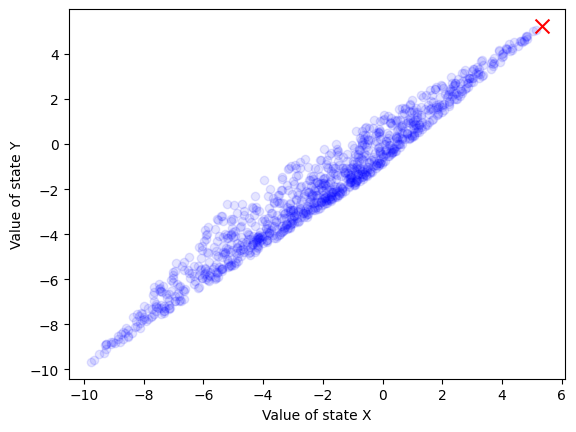

In [6]:
values = np.array(values)
plt.scatter(values[:, 0], values[:, 1], color='b', alpha=0.1)
v_pi_2 = bellman_equations(R, P, gamma, pi_2).flatten()
plt.scatter(v_pi_2[0], v_pi_2[1], color='r', marker='x', s=100)
plt.xlabel("Value of state X")
plt.ylabel("Value of state Y")
plt.show()